In [1]:
import numpy as np
import matplotlib.pyplot as plt

For a solid circular bar, the maximum shear stress occurs at the outer surface and is given by:

$$
\tau_{\text{max}} = \frac{T\,c}{J}
$$

Where:

- \(T\) = applied torque  
- \(c\) = outer radius of the shaft  
- \(J\) = polar moment of inertia for a solid circular section  

The polar moment of inertia for a solid circular bar is:

$$
J = \frac{\pi d^4}{32} = \frac{\pi (2c)^4}{32}
$$

So the equation becomes:

$$
\tau_{\text{max}} = \frac{16\,T}{\pi d^{3}}
$$

## Sizing

To size a circular shaft under torsion, the following strength criterion can be used:

$$
\tau_{\text{max}} = \frac{16T}{\pi d^{3}} \le \tau_{\text{allow}}
$$

Where:

- $\tau_{\text{allow}} = \frac{\tau_{\text{yield}}}{\text{FOS}}$
- FOS (factor of safety): typically **1.5–2** for static loading.

From this expression, the minimum shaft diameter for a given allowable shear stress and applied torque can be obtained:

$$
d_{\min} = \left( \frac{16T}{\pi \tau_{\text{allow}}} \right)^{1/3}
$$

The relationship between $T_1$ and $T_2$ is given by:


$$\frac{d_{T2}}{d_{T2}}=\frac{\sqrt[3]{\frac{16T_2}{\pi \tau_{\text{allow}}}}}{\sqrt[3]{\frac{16T_1}{\pi \tau_{\text{allow}}}}}=\sqrt[3]{\frac{T_2}{T_1}}$$

To obtain the minimum diameter for $T_2$, the following expression can be used:

$$d_{T2}=\sqrt[3]{\frac{T_2}{T_1}}d_{T1}$$


In [2]:
fty = 200 #MPa
awb_s = fty/1.5
print(f'Allowable Shear Stress: {awb_s:.2f} (MPa)', )

torques = np.linspace(2100, 60000, 10) # Nm

d_cm = lambda T, awb_s: ((16*T)/(np.pi*awb_s*1E6))**(1/3)*100

d_cm(torques[0], awb_s)



Allowable Shear Stress: 133.33 (MPa)


4.312709671069408

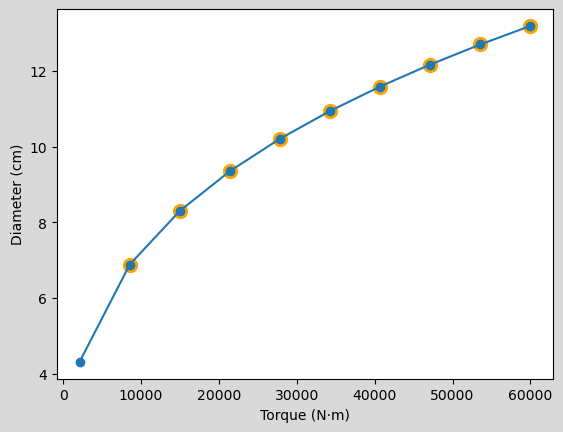

In [3]:
ds_cm = []

for torque in torques:
    ds_cm.append(d_cm(torque, awb_s))

cr_ratios = []

for n, torque in enumerate(torques[1:], start=1):
    cr_ratios.append((torque/torques[n-1])**(1/3))

f, ax = plt.subplots(facecolor='.85')
ax.plot(torques, ds_cm, '-o')

for n, cr_ratio in enumerate(cr_ratios):
    ax.scatter(torques[n+1], cr_ratio*ds_cm[n], color='orange', s=100)

ax.set_xlabel("Torque (N·m)")
ax.set_ylabel("Diameter (cm)")
plt.show()